Осы аптадағы тәжірибелік зертханада сіз бір конфигурацияны қолданып көресіз және бұл желілердің көптеген түрлерінің тіркесімі: деректер терезелері конвульсиядан өтеді, одан кейін жинақталған LSTM, содан кейін жинақталған тығыз қабаттар.

## Қажетті модульдерді импорттаңыз

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import csv

In [ ]:
def plot_series(x, y, format="-", start=0, end=None,
                title=None, xlabel=None, ylabel=None, legend=None ):
    """
    Уақыттық қатар деректерін визуалдау

    Параметрлер:
      x (бүтін сандар массиві) - x осіне арналған мәндерді қамтиды
      y (бүтін сандар массиві немесе массивтердің жұбы) - y осіне арналған мәндерді қамтиды
      format (жол) - график сызығының стилі
      start (бүтін сан) - графикте көрсетілетін бірінші уақыт қадамы
      end (бүтін сан) - графикте көрсетілетін соңғы уақыт қадамы
      title (жол) - графиктің тақырыбы
      xlabel (жол) - x осінің атауы
      ylabel (жол) - y осінің атауы
      legend (жолдар тізімі) - графиктің легендасы
    """

    # График фигурасының өлшемдерін орнату
    plt.figure(figsize=(10, 6))

    # Екіден көп қатарды графиктеу қажет пе екенін тексеру
    if type(y) is tuple:

      # y элементтері бойынша цикл жасау
      for y_curr in y:

        # x және ағымдағы y мәндерін графиктеу
        plt.plot(x[start:end], y_curr[start:end], format)

    else:
      # x және y мәндерін графиктеу
      plt.plot(x[start:end], y[start:end], format)

    # x осінің атауын белгілеу
    plt.xlabel(xlabel)

    # y осінің атауын белгілеу
    plt.ylabel(ylabel)

    # Легенданы орнату
    if legend:
      plt.legend(legend)

    # Тақырыпты орнату
    plt.title(title)

    # Графиктің үстіне тор сызбасын қосу
    plt.grid(True)

    # Экранда графикті көрсету
    plt.show()

## Деректер жинағын жүктеп алыңыз және алдын ала қараңыз

In [ ]:
import requests

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
response = requests.get(url)

with open("daily-min-temperatures.csv", "wb") as file:
    file.write(response.content)

print("Файл жүктелді!")

Файл жүктелді!


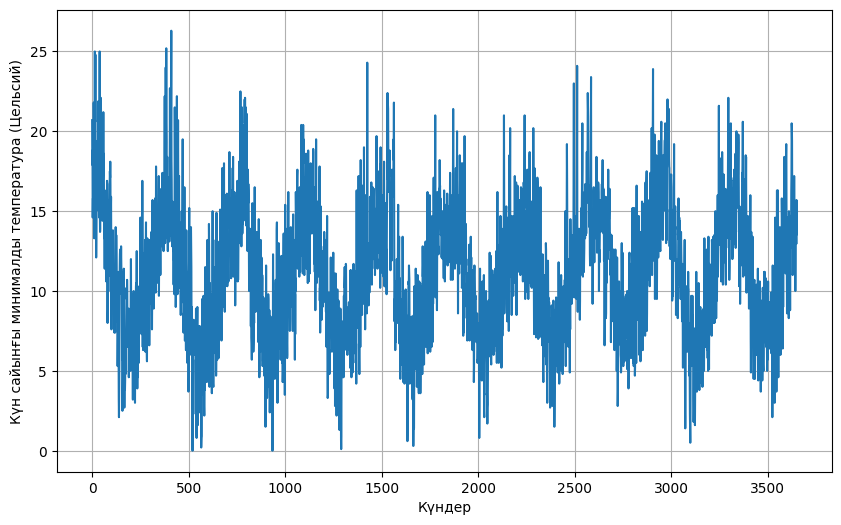

Файл жүктелді!


In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# Тізімдерді инициализациялау
time_step = []
temperatures = []

# CSV файлын ашу
with open('./daily-min-temperatures.csv') as csvfile:
    # Оқырманды инициализациялау
    reader = csv.reader(csvfile, delimiter=',')

    # Бірінші жолды өткізіп жіберу (баған атаулары)
    next(reader)

    # Әр жолдан уақыт қадамы мен температура мәнін тізімге қосу
    for index, row in enumerate(reader):
        time_step.append(index)  # Күндерді индекс арқылы қосамыз
        temperatures.append(float(row[1]))  # Температура мәні (екінші баған)

# Тізімдерді numpy массивтеріне ауыстыру
time = np.array(time_step)
series = np.array(temperatures)

# Деректерді алдын ала қарау үшін график салу
def plot_series(time, series, xlabel='', ylabel=''):
    plt.figure(figsize=(10, 6))
    plt.plot(time, series)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

# Деректерді графикте көрсету
plot_series(time, series, xlabel='Күндер', ylabel='Күн сайынғы минималды температура (Цельсий)')
import requests

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
response = requests.get(url)

with open("daily-min-temperatures.csv", "wb") as file:
    file.write(response.content)

print("Файл жүктелді!")


## Деректер жиынын бөліңіз

In [ ]:
# Define the split time
split_time = 3000

# Get the train set
time_train = time[:split_time]
x_train = series[:split_time]

# Get the validation set
time_valid = time[split_time:]
x_valid = series[split_time:]

## Мүмкіндіктер мен белгілерді дайындаңыз

In [ ]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Деректер жиынтығының терезелерін құрады

    Параметрлер:
      series (float сандар массиві) - уақыттық қатардың мәндерін қамтиды
      window_size (бүтін сан) - ерекшелікке енгізілетін уақыт қадамдарының саны
      batch_size (бүтін сан) - пакет көлемі
      shuffle_buffer (бүтін сан) - араластыру әдісі үшін қолданылатын буфер көлемі

    Қайтарады:
      dataset (TF Dataset) - уақыттық терезелерді қамтитын TF деректер жиынтығы
    """

    # RNN қабаттарының ерекшелік өлшемі үшін қосымша ось қосу
    series = tf.expand_dims(series, axis=-1)

    # Серия мәндерінен TF деректер жиынтығын жасау
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Деректерді терезеге бөлу, тек көрсетілген өлшемдегі терезелерді таңдау
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)

    # Терезелерді бір пакетке біріктіру арқылы тегістеу
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Ерекшеліктер мен белгілерді қамтитын кортеждерді жасау
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Терезелерді араластыру
    dataset = dataset.shuffle(shuffle_buffer)

    # Терезелердің пакеттерін жасау
    dataset = dataset.batch(batch_size)

    # Оқыту үшін деректер жиынтығын оңтайландыру
    dataset = dataset.cache().prefetch(1)

    return dataset

егер сіздің нәтижелеріңіз жақсы болмаса, мұнда параметрлерді өзгертуге және модельдің жақсырақ үйренетінін көруге болады.

In [ ]:
# Параметрлер
window_size = 30
batch_size = 32
shuffle_buffer_size = 1000

# Деректер жиынының терезелерін жасаңыз
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

## Үлгіні құрастыру

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size,1)),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3,
                      strides=1,
                      activation="relu",
                      padding='causal'),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 400)
])

# Үлгінің қысқаша мазмұнын басып шығарыңыз
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 30, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30)                  │           1,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             310 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,575 (267.87 KB)

 Trainable params: 68,575 (267.87 KB)

 Non-trainable params: 0 (0.00 B)

## Оқу жылдамдығын реттеңіз

оңтайлы оқу жылдамдығын таңдағыңыз келеді.

In [ ]:
# Бастапқы салмақтарды алыңыз
init_weights = model.get_weights()

In [ ]:
# Оқу жылдамдығын реттегішті орнату
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-8 * 10**(epoch / 20))

# Оптимизаторды инициализациялау
optimizer = tf.keras.optimizers.SGD(momentum=0.9)

# Оқыту параметрлерін орнату
model.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer)

# Модельді оқыту
history = model.fit(train_set, epochs=100, callbacks=[lr_schedule])

Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 81.2112 - learning_rate: 1.0000e-08
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 41.4279 - learning_rate: 1.1220e-08
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.7567 - learning_rate: 1.2589e-08
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.9774 - learning_rate: 1.4125e-08
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.3551 - learning_rate: 1.5849e-08
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0776 - learning_rate: 1.7783e-08
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.8962 - learning_rate: 1.9953e-08
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.7639 - learning_rate: 2.2387e-08
Epoch 9/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.6618 - learning_rate: 2.5119e-08
Epoch 10/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5816 - learning_rate: 2.8184e-08
Epoch 11/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5140 - learning_rate: 3.1623e-08
Epoch 12/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4587 - 

(np.float64(1e-08), np.float64(0.001), np.float64(0.0), np.float64(100.0))

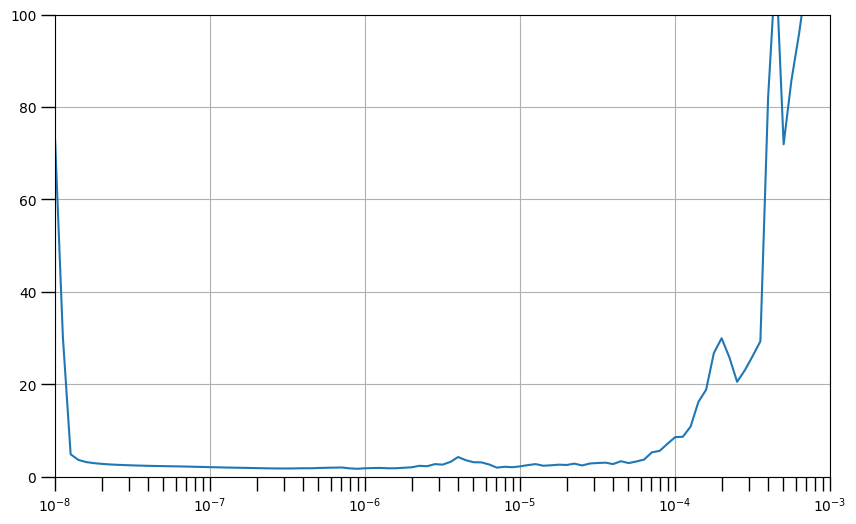

In [ ]:
# Оқу жылдамдығының массивін анықтау
lrs = 1e-8 * (10 ** (np.arange(100) / 20))

# Фигураның өлшемін орнату
plt.figure(figsize=(10, 6))

# Торды орнату
plt.grid(True)

# Логарифмдік масштабта жоғалту мәнін графиктеу
plt.semilogx(lrs, history.history["loss"])

# Тик белгішелерінің өлшемін ұлғайту
plt.tick_params('both', length=10, width=1, which='both')

# Графиктің шекараларын орнату
plt.axis([1e-8, 1e-3, 0, 100])

## Үлгіні жаттықтыру

Енді үлгіні қалпына келтіруге және үйретуге болады. Ол төмендегі ұяшықта 100 дәуірге орнатылған, бірақ қаласаңыз, оны көбейтуге болады.

In [ ]:
# Keras жасаған күйді қалпына келтіру
tf.keras.backend.clear_session()

# Салмақтарды қалпына келтіру
model.set_weights(init_weights)

In [ ]:
# Оқу жылдамдығын орнату
learning_rate = 8e-7

# Оптимизаторды орнату
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

# Оқыту параметрлерін орнату
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

In [ ]:
# Модельді оқыту
history = model.fit(train_set, epochs=100)

Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 24.5006 - mae: 24.9869
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2836 - mae: 2.7425
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0932 - mae: 2.5487
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0083 - mae: 2.4595
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9647 - mae: 2.4148
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9329 - mae: 2.3834
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8844 - mae: 2.3359
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8679 - mae: 2.3199
Epoch 9/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8671 - mae: 2.3194
Epoch 10/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8412 - mae: 2.2929
Epoch 11/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8225 - mae: 2.2735
Epoch 12/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8118 - mae: 2.2627
Epoch 13/100
93/93 ━━━━━━━━━━━━━━━━

Сіз жаттығуды визуализациялай аласыз және жоғалту мен MAE әлі де төмендейтінін көре аласыз.

In [ ]:
# Тарих жазбасынан mae және loss мәндерін алу
mae = history.history['mae']
loss = history.history['loss']

# Эпохалардың санын алу
epochs = range(len(loss))

# mae және loss графигін салу
plot_series(
    x=epochs,
    y=(mae, loss),
    title='MAE және Loss',
    xlabel='Эпоха',
    ylabel='Loss',
    legend=['MAE', 'Loss']
)

# Тек соңғы 80% эпохаларды графиктеу
zoom_split = int(epochs[-1] * 0.2)
epochs_zoom = epochs[zoom_split:]
mae_zoom = mae[zoom_split:]
loss_zoom = loss[zoom_split:]

# Үлкейтілген mae және loss графигін салу
plot_series(
    x=epochs_zoom,
    y=(mae_zoom, loss_zoom),
    title='MAE және Loss',
    xlabel='Эпоха',
    ylabel='Loss',
    legend=['MAE', 'Loss']
)

TypeError: plot_series() got an unexpected keyword argument 'x'

## Модель болжауы

Алдыңғыдай, валидациялық жиынтықтың уақыт диапазоны бойынша болжамдарды алып, метрикаларды есептей аласыз.

In [ ]:
def model_forecast(model, series, window_size, batch_size):
    """Модельді қолданып, деректер терезелеріндегі болжамдарды генерациялайды

    Параметрлер:
      model (TF Keras Model) - деректер терезелерін қабылдайтын модель
      series (float сандар массиві) - уақыттық қатардың мәндерін қамтиды
      window_size (бүтін сан) - терезеге енгізілетін уақыт қадамдарының саны
      batch_size (бүтін сан) - пакет көлемі

    Қайтарады:
      forecast (numpy массиві) - болжамдарды қамтитын массив
    """

    # RNN қабаттарының ерекшелік өлшемі үшін қосымша ось қосу
    series = tf.expand_dims(series, axis=-1)

    # Серия мәндерінен TF деректер жиынтығын жасау
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Деректерді терезеге бөлу, тек көрсетілген өлшемдегі терезелерді таңдау
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)

    # Терезелерді бір пакетке біріктіру арқылы тегістеу
    dataset = dataset.flat_map(lambda w: w.batch(window_size))

    # Терезелердің пакеттерін жасау және алдын ала жүктеу
    dataset = dataset.batch(batch_size).prefetch(1)

    # Барлық деректер жиынтығына болжам алу
    forecast = model.predict(dataset, verbose=0)

    return forecast


In [ ]:
# Түпнұсқа қатарды қысқарту
forecast_series = series[split_time-window_size:-1]

# Болжамдарды генерациялау үшін көмекші функцияны қолдану
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Бірөлшемді осьті алып тастау
results = forecast.squeeze()

# Нәтижелерді графиктеу
plot_series(time_valid, (x_valid, results))

In [ ]:
# Compute the MAE
print(tf.keras.metrics.mae(x_valid, results).numpy())

## Тапсырма

Уақыт қатарларының деректер жинағын желіден табыңыз немесе оны өзіңіз талдай аласыз, берілген үлгіні пайдаланып уақыт қатарының болжамын жасаңыз

Epoch 1/20


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.3651 - val_loss: 0.0145
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0212 - val_loss: 0.0052
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0065 - val_loss: 0.0049
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0050 - val_loss: 0.0069
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0040 - val_loss: 0.0086
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0037 - val_loss: 0.0084
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0037 - val_loss: 0.0088
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0032 - val_loss: 0.0080
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0030 - val_loss: 0.0077
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0029 - val_loss: 0.0055
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0029 - val_loss: 0.0054
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0026 - val_l

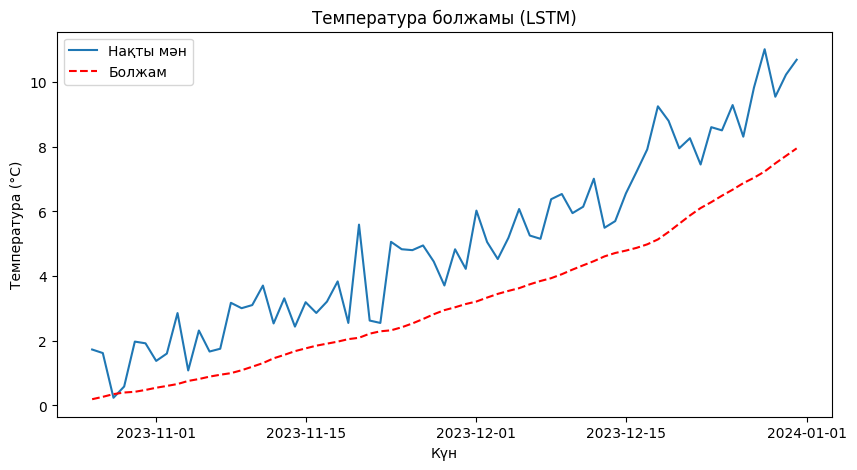

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Уақыт қатарлары үшін синтетикалық деректер жасау (мысалы, күнделікті температура)
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", periods=365, freq="D")
temperatures = 10 + 10 * np.sin(np.linspace(0, 2 * np.pi, 365)) + np.random.normal(0, 1, 365)
df = pd.DataFrame({"date": dates, "temperature": temperatures})

# Деректерді шкалалау (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
df["scaled_temp"] = scaler.fit_transform(df[["temperature"]])

# Уақыт терезелерін жасау

def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

# Терезе ұзындығы
seq_length = 30
X, y = create_sequences(df["scaled_temp"].values, seq_length)

# Мәліметтерді бөлу (80% - оқыту, 20% - тест)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# LSTM үлгісін құру
model = Sequential([
    LSTM(50, activation="relu", return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, activation="relu"),
    Dense(1)
])

# Модельді компиляциялау
model.compile(optimizer="adam", loss="mse")

# Үлгіні үйрету
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Болжам жасау
predictions = model.predict(X_test)

# Нәтижені бастапқы масштабқа қайтару
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
pred_rescaled = scaler.inverse_transform(predictions)

# График салу
plt.figure(figsize=(10, 5))
plt.plot(df["date"][split+seq_length:], y_test_rescaled, label="Нақты мән")
plt.plot(df["date"][split+seq_length:], pred_rescaled, label="Болжам", linestyle="dashed", color="red")
plt.legend()
plt.title("Температура болжамы (LSTM)")
plt.xlabel("Күн")
plt.ylabel("Температура (°C)")
plt.show()


In [ ]:
print(f"(MAE): {np.mean(mae)}")

(MAE): 1.7257165908813477


Epoch 1/100


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.1788 - val_loss: 0.0027
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0239 - val_loss: 0.0021
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0209 - val_loss: 0.0101
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0139 - val_loss: 0.0098
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0129 - val_loss: 0.0121
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0123 - val_loss: 0.0162
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0096 - val_loss: 0.0133
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0094 - val_loss: 0.0055
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0112 - val_loss: 0.0057
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0090 - val_loss: 0.0092
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0093 - val_loss: 0.0081
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0

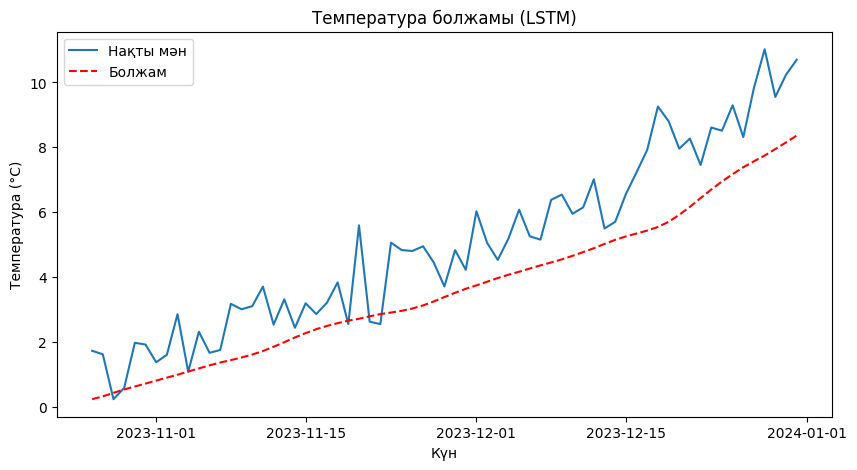

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Уақыт қатарлары үшін синтетикалық деректер жасау (мысалы, күнделікті температура)
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", periods=365, freq="D")
temperatures = 10 + 10 * np.sin(np.linspace(0, 2 * np.pi, 365)) + np.random.normal(0, 1, 365)
df = pd.DataFrame({"date": dates, "temperature": temperatures})

# Деректерді шкалалау (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
df["scaled_temp"] = scaler.fit_transform(df[["temperature"]])

# Уақыт терезелерін жасау
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

# Терезе ұзындығы
seq_length = 30
X, y = create_sequences(df["scaled_temp"].values, seq_length)

# Мәліметтерді бөлу (80% - оқыту, 20% - тест)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Деректерді LSTM-ға сай өлшемге келтіру
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# LSTM үлгісін құру
model = Sequential([
    LSTM(64, activation="tanh", return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(64, activation="tanh", return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

# Модельді компиляциялау
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss="mse")

# Үлгіні үйрету
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Болжам жасау
predictions = model.predict(X_test)

# Нәтижені бастапқы масштабқа қайтару
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
pred_rescaled = scaler.inverse_transform(predictions)

# MAE есептеу
mae = tf.keras.metrics.mae(y_test_rescaled, pred_rescaled).numpy()
print(f"Mean Absolute Error (MAE): {mae}")

# График салу
plt.figure(figsize=(10, 5))
plt.plot(df["date"][split+seq_length:], y_test_rescaled, label="Нақты мән")
plt.plot(df["date"][split+seq_length:], pred_rescaled, label="Болжам", linestyle="dashed", color="red")
plt.legend()
plt.title("Температура болжамы (LSTM)")
plt.xlabel("Күн")
plt.ylabel("Температура (°C)")
plt.show()

In [ ]:
print(f"(MAE): {np.mean(mae)}")

(MAE): 1.3703168630599976
